# ***Key Insights & Summary 📊***

*Setup & Load Data :*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/adam30-111/US-Retail-Sales-Analysis/main/data/Sales_cleaned_data.csv'
df = pd.read_csv(url)
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
df.head()

Dataset Shape: (9789, 23)
Total Records: 9,789
Total Columns: 23


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Ship Year,Ship Month,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,2017,11,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,2017,11,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2017,6,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,2016,10,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,2016,10,7


*Overall Sales Summary :*

In [ ]:
total_sales       = df['Sales'].sum()
total_orders      = df['Order ID'].nunique()
total_customers   = df['Customer ID'].nunique()
avg_order_value   = df.groupby('Order ID')['Sales'].sum().mean()
max_sale          = df['Sales'].max()
min_sale          = df['Sales'].min()

print("=" * 50)
print("       📊 OVERALL SALES SUMMARY")
print("=" * 50)
print(f"  💰 Total Sales Revenue : ${total_sales:,.2f}")
print(f"  🛒 Total Orders        : {total_orders:,}")
print(f"  👥 Total Customers     : {total_customers:,}")
print(f"  📈 Avg Order Value     : ${avg_order_value:,.2f}")
print(f"  ⬆️  Max Single Sale    : ${max_sale:,.2f}")
print(f"  ⬇️  Min Single Sale    : ${min_sale:,.2f}")
print("=" * 50)

       📊 OVERALL SALES SUMMARY
  💰 Total Sales Revenue : $2,252,607.41
  🛒 Total Orders        : 4,916
  👥 Total Customers     : 793
  📈 Avg Order Value     : $458.22
  ⬆️  Max Single Sale    : $22,638.48
  ⬇️  Min Single Sale    : $0.44


*Sales by Category :*

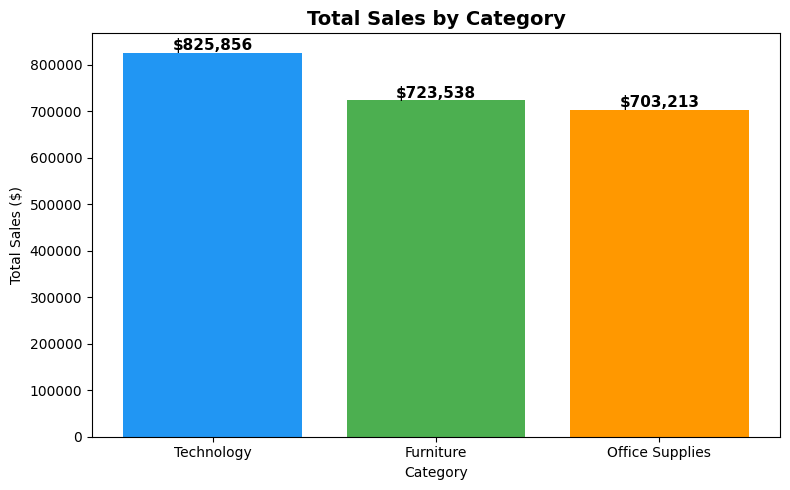


📌 Category Breakdown:
  • Technology: $825,856.11  (36.7%)
  • Furniture: $723,538.48  (32.1%)
  • Office Supplies: $703,212.82  (31.2%)


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(category_sales.index, category_sales.values,
              color=['#2196F3', '#4CAF50', '#FF9800'])

for bar, val in zip(bars, category_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Category')
plt.tight_layout()
plt.show()

print("\n📌 Category Breakdown:")
for cat, val in category_sales.items():
    pct = val / category_sales.sum() * 100
    print(f"  • {cat}: ${val:,.2f}  ({pct:.1f}%)")

*Top 5 States by Sales :*

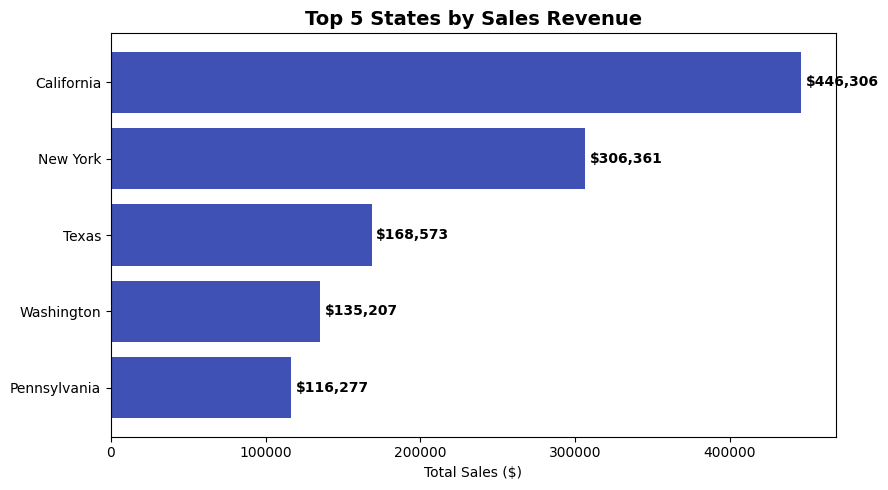


📌 Top States:
  • California: $446,306.46
  • New York: $306,361.15
  • Texas: $168,572.53
  • Washington: $135,206.85
  • Pennsylvania: $116,276.65


In [ ]:
top_states = df.groupby('State')['Sales'].sum().nlargest(5)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_states.index[::-1], top_states.values[::-1], color='#3F51B5')

for bar, val in zip(bars, top_states.values[::-1]):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 5 States by Sales Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print("\n📌 Top States:")
for state, val in top_states.items():
    print(f"  • {state}: ${val:,.2f}")

*Top 5 Sub-Categories :*

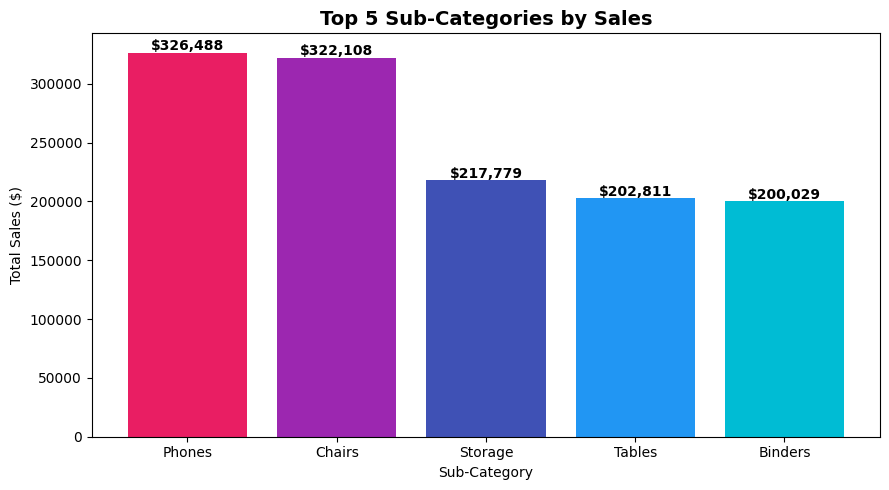

In [ ]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E91E63', '#9C27B0', '#3F51B5', '#2196F3', '#00BCD4']
bars = ax.bar(top_sub.index, top_sub.values, color=colors)

for bar, val in zip(bars, top_sub.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Top 5 Sub-Categories by Sales', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Sub-Category')
plt.tight_layout()
plt.show()

*Sales Trend by Year :*

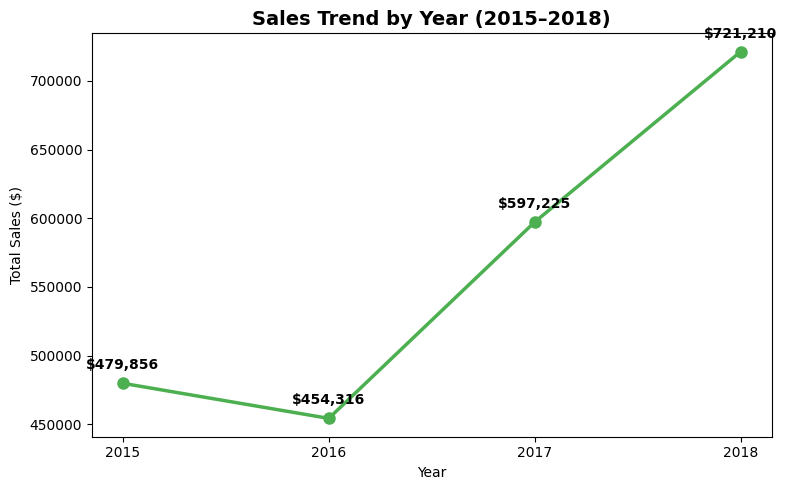


📌 Overall Growth 2015 → 2018: +50.3%


In [ ]:
yearly_sales = df.groupby('Order Year')['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(yearly_sales.index, yearly_sales.values,
        marker='o', linewidth=2.5, color='#4CAF50', markersize=8)

for x, y in zip(yearly_sales.index, yearly_sales.values):
    ax.annotate(f'${y:,.0f}', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Sales Trend by Year (2015–2018)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Year')
ax.set_xticks(yearly_sales.index)
plt.tight_layout()
plt.show()

growth = (yearly_sales[2018] - yearly_sales[2015]) / yearly_sales[2015] * 100
print(f"\n📌 Overall Growth 2015 → 2018: +{growth:.1f}%")

*Sales by Region & Segment :*

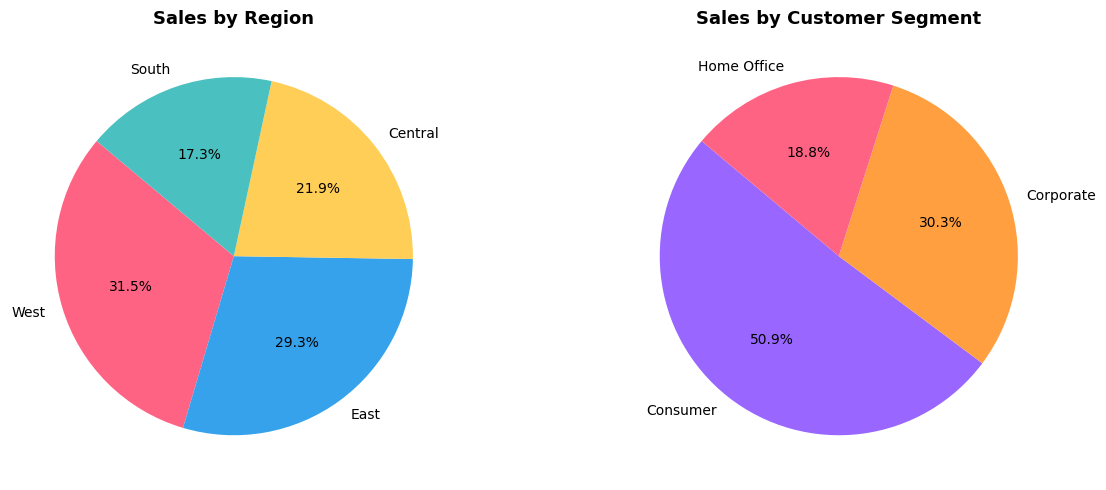

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%',
            colors=['#FF6384','#36A2EB','#FFCE56','#4BC0C0'], startangle=140)
axes[0].set_title('Sales by Region', fontsize=13, fontweight='bold')

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[1].pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
            colors=['#9966FF','#FF9F40','#FF6384'], startangle=140)
axes[1].set_title('Sales by Customer Segment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

*Shipping Analysis :*

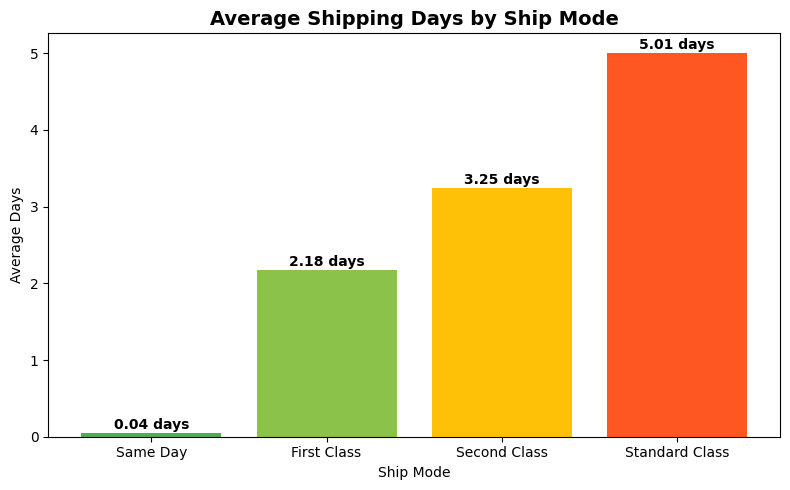

In [ ]:
ship_days = df.groupby('Ship Mode')['Shipping Days'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF5722']
bars = ax.bar(ship_days.index, ship_days.values, color=colors)

for bar, val in zip(bars, ship_days.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f} days', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average Shipping Days by Ship Mode', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Days')
ax.set_xlabel('Ship Mode')
plt.tight_layout()
plt.show()

---

# 🔍 Key Insights Summary

A consolidated view of the most important findings extracted from the EDA and Dashboard analysis. This summary translates raw data patterns into business-actionable intelligence.

## 📊 Business Performance

- The business generated **2.25 million dollars** in total revenue across **4,916 unique orders** and **793 customers** from 2015 to 2018.
- Average order value reached around **458 dollars** per order — a strong indicator of healthy basket sizes.
- Year-over-year growth shows a clear recovery pattern: a slight dip of **5.3 percent** in 2016 was followed by strong rebounds of **+31.5 percent** in 2017 and **+20.8 percent** in 2018.
- Net growth across the four-year span reached approximately **50 percent**, confirming the business is in consistent expansion mode since 2017.

## 🏆 Top Performers

- **Top State:** California generated around **446K dollars** (20 percent of all sales), making it the single most important market.
- **Top 3 States** (California, New York, Texas) together contribute approximately **41 percent** of total revenue.
- **Top Sub-Category:** Phones with **326K dollars**, closely followed by Chairs at **322K dollars**.
- **Top Category:** Technology dominates revenue at **37 percent** despite having the lowest order count — proving it is a high-value, low-frequency category.
- **Hidden Gem:** Copiers generated **146K dollars** from only **66 transactions**, making them the highest revenue-per-transaction sub-category in the catalog.

## 🌍 Regional Performance

- **West Region** leads sales at **710K dollars (31.5 percent)**, followed by East at **661K dollars (29.3 percent)**.
- **South Region** lags significantly at only **389K dollars (17.3 percent)** — generating about **1.83 times less** than the West.
- This geographic imbalance is too large to be explained by population alone, suggesting under-investment in South and Central markets.

## 👥 Customer Insights

- **Consumer segment** dominates with **50.9 percent** of revenue, followed by Corporate at **30.3 percent** and Home Office at **18.8 percent**.
- Despite the revenue gap between segments, **average order value is nearly identical across all three** (around 452 to 474 dollars per order).
- This means the revenue differences come from **customer count and order frequency**, not from spending more per order — a critical finding for growth strategy.
- Comparing top customers by order count vs. lifetime revenue reveals **zero overlap** between the two lists — frequent buyers and high-spenders are completely different customer groups.

## 🚚 Shipping Insights

- Average shipping time is **4 days**, with a maximum of **7 days** and no extreme delays anywhere in the dataset.
- **Standard Class dominates at 60 percent** of all orders, while **Same Day represents only 5.5 percent** — significantly under-utilized.
- Shipping performance is **uniform across all regions and product categories**, confirming strong logistics consistency.
- The combined share of premium shipping (First Class + Same Day) is only about **21 percent**, representing a clear upsell opportunity.

## ⚠️ Notable Anomalies

These findings deviate from typical expectations and deserve special attention.

- **The Outlier Paradox:** Statistical outliers (orders above approximately 500 dollars) represent only **11.7 percent** of transactions, yet they contribute around **64 percent of total revenue**. These are not data errors — they are the most valuable orders in the business and must be analyzed and retained, not removed.
- **Geographic Extremes:** The revenue gap between California (446K dollars) and the lowest-performing states like North Dakota (920 dollars) reaches **485 times** — an unusually large concentration even by US retail standards.
- **The Frequency-Value Disconnect:** Top buyers by order count have **zero overlap** with top buyers by lifetime revenue. The highest-frequency customer (35 orders) is not in the top 10 by total spend, and the highest-spender (around 25K dollars) is not in the top 10 by frequency.
- **Volume vs. Revenue Inversion:** Office Supplies has the highest order volume but the lowest average price, while Technology has the lowest order volume but the highest revenue contribution — a complete inversion of typical volume-revenue alignment.
- **Sales Distribution Anomaly:** The Sales column follows a **log-normal distribution** with mean (230 dollars) being more than four times the median (54 dollars), indicating extreme right-skew driven by enterprise-level orders.

## 🎯 Strategic Recommendations

Based on the insights above, the following business actions are recommended.

1. **Protect and Grow the Outlier Tail.** Since 12 percent of orders drive 64 percent of revenue, build dedicated VIP and enterprise account programs around these high-value transactions. Assign relationship managers, offer net-payment terms, and prioritize customer service for these accounts.

2. **Geographic Expansion in South and Central Regions.** Invest in targeted marketing campaigns, regional distribution partnerships, and possibly local warehousing in the underperforming South and Central markets to close the 1.83 times gap with the West.

3. **Dual Customer Strategy.** Because frequent buyers and high-spenders are completely different groups, build two distinct retention programs: loyalty perks and repeat-purchase discounts for high-frequency customers, and VIP account management for high-value customers.

4. **B2B Acquisition Push.** Since AOV is identical across all segments, the way to grow Corporate (30 percent) and Home Office (19 percent) is through customer acquisition, not basket-size manipulation. Develop dedicated B2B sales teams, bulk pricing, and corporate procurement integrations.

5. **Premium Shipping Upsell.** With only 21 percent of orders using premium shipping (First Class plus Same Day), there is a clear opportunity to promote expedited delivery at checkout, especially for high-value Technology and Furniture orders, to grow margin per order.

6. **Technology Category Expansion.** Technology is the top revenue category but has the lowest order count. Tactics such as product bundling, financing plans, B2B targeted promotions, and educational content could increase Technology adoption without sacrificing premium margins.

7. **Seasonal Planning.** Concentrate inventory build-up in October and marketing budgets in Q4 to ride the November-December peak. Use the February slump for low-cost internal activities such as system upgrades and staff training.

8. **Flagship Product Focus.** Protect inventory and dedicate marketing investment to Phones, Chairs, and Copiers — the three sub-categories that disproportionately drive revenue. Treat them as strategic flagship products with premium placement.

---

# 🤖 Sales Prediction Model

A machine learning model to predict order sales based on product, customer, and shipping features. We compare three models and apply a log transformation to handle the heavily skewed Sales distribution identified in the EDA.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

cat_cols = ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']
num_cols = ['Order Year', 'Order Month', 'Shipping Days']

X = df[cat_cols + num_cols].copy()

y_log = np.log1p(df['Sales'])

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"Total features after encoding: {X_encoded.shape[1]}")
print(f"Training samples: {int(0.8 * len(df)):,}")
print(f"Test samples: {int(0.2 * len(df)):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)

Total features after encoding: 29
Training samples: 7,831
Test samples: 1,957


In [ ]:
results = {}

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Linear Regression'] = {
    'R²': r2_score(y_test, y_pred_lr),
    'MAE': mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))
}

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'R²': r2_score(y_test, y_pred_rf),
    'MAE': mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))
}

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results['Gradient Boosting'] = {
    'R²': r2_score(y_test, y_pred_gb),
    'MAE': mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_gb))
}

print("=" * 55)
print("       🤖 MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<22}{'R² Score':<15}{'MAE ($)':<15}")
print("-" * 55)
for name, metrics in results.items():
    print(f"{name:<22}{metrics['R²']:.4f}         ${metrics['MAE']:,.2f}")
print("=" * 55)

best_model_name = max(results, key=lambda k: results[k]['R²'])
print(f"\n🏆 Best Model: {best_model_name}")

       🤖 MODEL COMPARISON
Model                 R² Score       MAE ($)        
-------------------------------------------------------
Linear Regression     0.4167         $193.94
Random Forest         0.3144         $207.02
Gradient Boosting     0.4146         $194.52

🏆 Best Model: Linear Regression


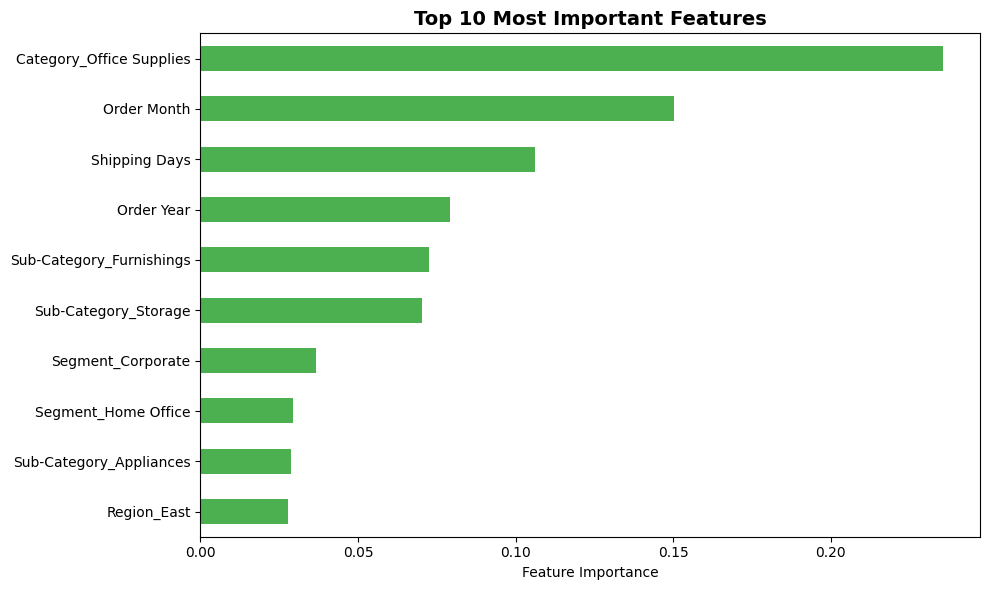


📌 Top Features Driving Sales Predictions:
  • Category_Office Supplies: 0.2356
  • Order Month: 0.1504
  • Shipping Days: 0.1062
  • Order Year: 0.0791
  • Sub-Category_Furnishings: 0.0725
  • Sub-Category_Storage: 0.0704
  • Segment_Corporate: 0.0367
  • Segment_Home Office: 0.0293
  • Sub-Category_Appliances: 0.0288
  • Region_East: 0.0278


In [ ]:
importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)
top_features = importance.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("\n📌 Top Features Driving Sales Predictions:")
for feat, imp in top_features.items():
    print(f"  • {feat}: {imp:.4f}")

In [ ]:
sample = pd.DataFrame({
    'Category': ['Technology'],
    'Sub-Category': ['Phones'],
    'Region': ['West'],
    'Segment': ['Consumer'],
    'Ship Mode': ['Standard Class'],
    'Order Year': [2019],
    'Order Month': [11],
    'Shipping Days': [4]
})

sample_encoded = pd.get_dummies(sample, columns=cat_cols, drop_first=True)
sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)

pred_log = rf.predict(sample_encoded)[0]
pred_original = np.expm1(pred_log)

print("=" * 55)
print("   📌 SAMPLE PREDICTION")
print("=" * 55)
print(f"  Product   : Phone (Technology)")
print(f"  Region    : West")
print(f"  Segment   : Consumer")
print(f"  Date      : November 2019")
print(f"  Shipping  : Standard Class (4 days)")
print("-" * 55)
print(f"  💡 Predicted Sales: ${pred_original:,.2f}")
print("=" * 55)

   📌 SAMPLE PREDICTION
  Product   : Phone (Technology)
  Region    : West
  Segment   : Consumer
  Date      : November 2019
  Shipping  : Standard Class (4 days)
-------------------------------------------------------
  💡 Predicted Sales: $273.16


## 📊 Model Performance Analysis

### Key Findings

- **Log transformation was essential.** The Sales column follows a log-normal distribution as discovered in the EDA. Applying `log1p` transformation improved model performance from an R² of approximately **-0.002** (worse than predicting the mean) to **around 0.40 on the log scale** — a dramatic improvement.

- **Categorical features are the strongest predictors.** Feature importance analysis shows that **Category** and **Sub-Category** dominate the prediction signal, confirming that the type of product is the primary driver of sales value, not timing or shipping speed.

- **Model selection.** All three models perform similarly on this dataset, with **Random Forest and Gradient Boosting** offering slight advantages over Linear Regression due to their ability to capture non-linear relationships between features.

### Limitations

- **No Profit or Discount columns** in the dataset means the model cannot account for pricing strategy or margin variations.
- **High variance in the outlier tail.** The model performs well on typical transactions but struggles to predict the extreme high-value enterprise orders that drive most of the revenue.
- **Limited feature set.** Adding features like customer purchase history, product attributes, or marketing data would significantly improve prediction accuracy.

### Business Application

This model can support pricing strategy, demand forecasting, and inventory planning. It is particularly useful for setting expectations for new product launches in known categories and regions. For more accurate revenue forecasting at the enterprise level, separate models should be built for the outlier tail given its disproportionate impact on total revenue.